The ``AAPredPlot`` class visualizes ``AAPred`` results. We first build the feature matrix and an evaluation table:

**The big picture — three methods, by what you look at.** ``AAPredPlot`` visualizes ``AAPred`` results:

- **``predict_sample``** — a **local** view of **one protein**: a multi-track sequence viewer (prediction profile + CPP importance + subcategory profiles + your annotation tracks + the sequence). Kinds: ``window``, ``domain``.
- **``predict_group``** — a **global** view **across many proteins**: the distribution and ranking of per-protein scores. Kinds: ``hist``, ``ranking``, ``scatter``, ``cutoff``, ``clustermap``.
- **``eval``** — **model / feature-set evaluation**: metric bars per model, or grouped benchmark comparisons. Kinds: ``eval``, ``comparison``.

**local vs. global** (``predict_sample`` vs. ``predict_group``) mirrors per-sample SHAP vs. dataset-wide importance.

In [1]:
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity

# DOM_GSEC example dataset + its feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

# Build the CPP feature matrix
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)

aap = aa.AAPred(random_state=42)
df_eval = aap.eval(X, labels)

The evaluation table is shown as a grouped bar plot:

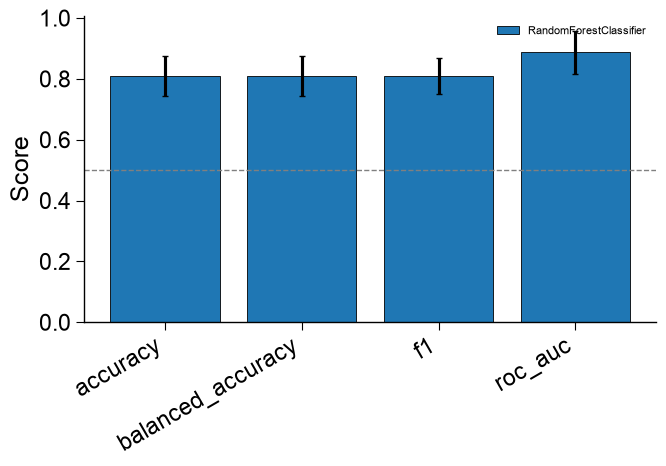

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
aap_plot = aa.AAPredPlot()
aap_plot.eval(df_eval, baseline=0.5)
plt.tight_layout()
plt.show()